# Analytics Gallery with pycensuskr

In [1]:
from pycensuskr import CensusKR
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

census = CensusKR()


## Example 1: Spatial autocorrelation of economic activity

This section uses `libpysal` and `esda`. Install once if needed.


/tmp/ipykernel_1881984/3069906930.py:11: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(sf)
/home/isong/GitHub/pycensuskr/.venv/lib/python3.12/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 10 disconnected components.
 There are 8 islands with ids: 3, 13, 15, 52, 171, 206, 245, 249.
  W.__init__(self, neighbors, ids=ids, **kw)
/home/isong/GitHub/pycensuskr/.venv/lib/python3.12/site-packages/esda/moran.py:1354: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim


('WARNING: ', 3, ' is an island (no neighbors)')
('WARNING: ', 13, ' is an island (no neighbors)')
('WARNING: ', 15, ' is an island (no neighbors)')
('WARNING: ', 52, ' is an island (no neighbors)')
('WARNING: ', 171, ' is an island (no neighbors)')
('WARNING: ', 206, ' is an island (no neighbors)')
('WARNING: ', 245, ' is an island (no neighbors)')
('WARNING: ', 249, ' is an island (no neighbors)')
Global Moran I: 0.43860706892754575
p-value: 0.001


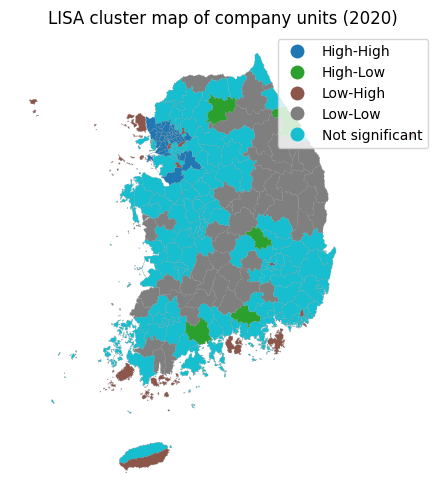

In [6]:
# Uncomment once if needed:
# !pip install libpysal esda

from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local

adm2_2020 = census.load_districts(2020)
df_econ = census.anycensus(year=2020, type='economy')
sf = adm2_2020.merge(df_econ[['adm2_code', 'company_total_cou']], on='adm2_code', how='inner')

w = Queen.from_dataframe(sf)
w.transform = 'r'

y = sf['company_total_cou'].fillna(0).to_numpy()

m = Moran(y, w)
print('Global Moran I:', m.I)
print('p-value:', m.p_sim)

lm = Moran_Local(y, w)
mean_y = y.mean()

def lisa_class(val, z, p):
    if p > 0.05:
        return 'Not significant'
    if val > mean_y and z > 0:
        return 'High-High'
    if val < mean_y and z > 0:
        return 'Low-Low'
    if val > mean_y and z < 0:
        return 'High-Low'
    return 'Low-High'

sf['cluster'] = [lisa_class(v, z, p) for v, z, p in zip(y, lm.Is, lm.p_sim)]

ax = sf.plot(column='cluster', categorical=True, legend=True, figsize=(8, 6), linewidth=0.1, edgecolor='gray')
ax.set_title('LISA cluster map of company units (2020)')
ax.set_axis_off()
plt.show()
